In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load Dataset (Ganti dengan dataset proyek Anda)
from sklearn.datasets import load_iris
df = pd.read_csv('creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

In [2]:
# 2. Preprocessing
# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Sangat disarankan untuk Softmax/Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
# 3. Inisialisasi Model
# A. Softmax Regression (Tanpa parameter multi_class karena sudah otomatis di versi terbaru)
softmax_model = LogisticRegression(solver='lbfgs', max_iter=1000)

# B. One-vs-All (OvA)
ova_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))

# C. One-vs-One (OvO)
ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=1000))

In [4]:
# 4. Pelatihan Model (Fitting)
softmax_model.fit(X_train, y_train)
ova_model.fit(X_train, y_train)
ovo_model.fit(X_train, y_train)

# 5. Evaluasi dan Perbandingan Performa
models = {
    "Softmax Regression": softmax_model,
    "One-vs-All (OvA)": ova_model,
    "One-vs-One (OvO)": ovo_model
}

print("HASIL PERBANDINGAN PERFORMA MODEL:")
print("=" * 60)

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Model: {name}")
    print(f"Accuracy Score: {acc:.4f}")
    print("-" * 30)
    print(classification_report(y_test, y_pred))
    print("=" * 60)

HASIL PERBANDINGAN PERFORMA MODEL:
Model: Softmax Regression
Accuracy Score: 0.9991
------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962

Model: One-vs-All (OvA)
Accuracy Score: 0.9991
------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962

Model: One-vs-One (OvO)
Accuracy Score: 0.9991
------------------------------
              precision    recall  f1-score   support

           0       1

In [5]:
# Jalankan ini di cell baru untuk melihat ringkasan tanpa terpotong
data_summary = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    data_summary.append({"Model": name, "Accuracy": f"{acc:.4f}"})

# Menampilkan dalam bentuk DataFrame agar rapi dan tidak terpotong
summary_df = pd.DataFrame(data_summary)
print("RINGKASAN AKURASI SEMUA MODEL:")
print(summary_df)

# Menampilkan khusus Classification Report OvO yang tadi tersembunyi
print("\nDETAIL PERFORMA ONE-VS-ONE (OvO):")
print("-" * 30)
y_pred_ovo = models["One-vs-One (OvO)"].predict(X_test)
print(classification_report(y_test, y_pred_ovo))

RINGKASAN AKURASI SEMUA MODEL:
                Model Accuracy
0  Softmax Regression   0.9991
1    One-vs-All (OvA)   0.9991
2    One-vs-One (OvO)   0.9991

DETAIL PERFORMA ONE-VS-ONE (OvO):
------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962



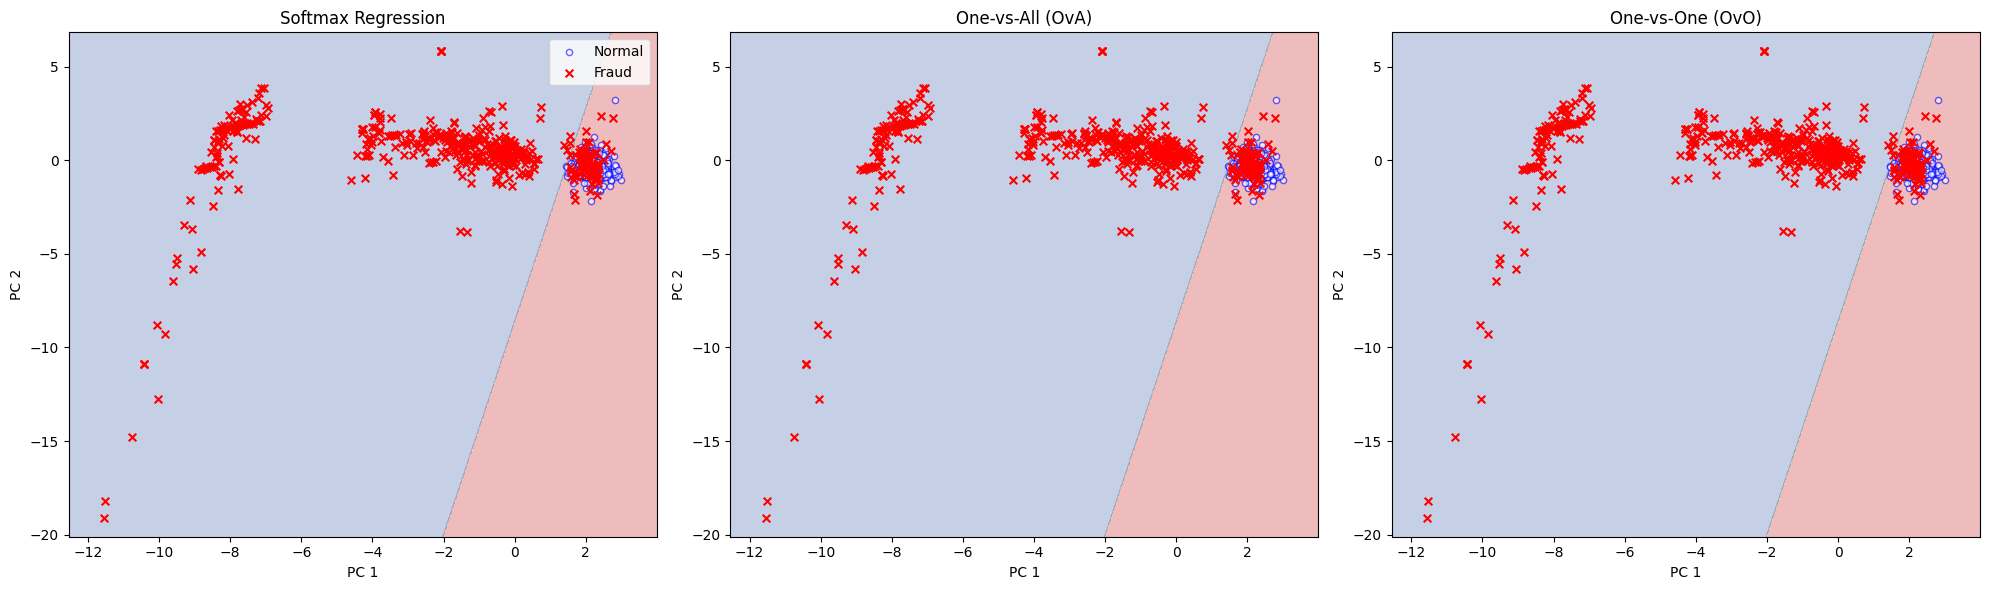

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load Data dan Sampling
df = pd.read_csv('creditcard.csv')
# Ambil sampel agar proses plotting cepat dan tidak berantakan
df_sample = pd.concat([
    df[df['Class'] == 0].sample(500, random_state=42),
    df[df['Class'] == 1]
])

X = df_sample.drop('Class', axis=1)
y = df_sample['Class']

# 2. Preprocessing & PCA (2 Komponen agar bisa diplot 2D)
scaler = StandardScaler()
X_pca = PCA(n_components=2).fit_transform(scaler.fit_transform(X))

# 3. Inisialisasi 3 Metode
models = [
    ("Softmax Regression", LogisticRegression(solver='lbfgs', max_iter=1000)),
    ("One-vs-All (OvA)", OneVsRestClassifier(LogisticRegression(max_iter=1000))),
    ("One-vs-One (OvO)", OneVsOneClassifier(LogisticRegression(max_iter=1000)))
]

# 4. Membuat Plot untuk Setiap Metode
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tentukan batas grid untuk gambar background warna
h = .02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

for i, (name, model) in enumerate(models):
    # Training model pada data PCA
    model.fit(X_pca, y)
    
    # Prediksi area grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Gambar area warna (Decision Boundary)
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # Plot titik data
    axes[i].scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], c='white', edgecolors='blue', 
                    marker='o', s=20, label='Normal', alpha=0.6)
    axes[i].scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], c='red', 
                    marker='x', s=30, label='Fraud')
    
    axes[i].set_title(name)
    axes[i].set_xlabel("PC 1")
    axes[i].set_ylabel("PC 2")
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()